In [110]:
!pip install xgboost
!pip install imbalanced-learn

In [111]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [112]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [114]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [115]:
# Convert 'TotalCharges' to numeric and fill NaN values before defining X and y
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

X = df.drop(["Churn", "customerID"], axis=1)
y = df["Churn"]


### Check for Missing Values
Next, we'll check for any missing values across all columns.

In [116]:
print('Number of null values per column:')
display(df.isnull().sum())

Number of null values per column:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Check for Duplicate Rows
Let's see if there are any duplicate rows in the dataset.

In [117]:
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


### Sum of Numeric Columns
Finally, let's calculate the sum of all numeric columns.

In [118]:
print('Sum of numeric columns:')
display(df.sum(numeric_only=True))

Sum of numeric columns:


,0
SeniorCitizen,1142.0
tenure,227990.0
MonthlyCharges,456116.6
TotalCharges,16056168.7
Churn,1869.0


### Convert 'TotalCharges' to Numeric
As observed from `df.info()`, the 'TotalCharges' column is of `object` type. We need to convert it to a numeric type to perform calculations. We'll use `pd.to_numeric` with `errors='coerce'` to convert any non-numeric values to `NaN`.

In [119]:
print("DataFrame info after ensuring 'TotalCharges' is numeric and filled:")
df.info()


DataFrame info after ensuring 'TotalCharges' is numeric and filled:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          704

### Check for New Missing Values after Conversion
Now that 'TotalCharges' has been converted, let's check if any `NaN` values were introduced during the coercion.

In [120]:
print('Number of null values after converting TotalCharges:')
display(df.isnull().sum())

Number of null values after converting TotalCharges:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Identify Numerical & Categorical Columns
We'll explicitly define our numerical and categorical column lists for preprocessing.

In [121]:
numerical_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Defensive check: Ensure TotalCharges is not accidentally in categorical_cols if it's numeric
if "TotalCharges" in categorical_cols:
    categorical_cols.remove("TotalCharges")

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Exploratory Data Analysis (EDA)
Let's visualize the distribution of key numerical and categorical features to gain insights into the dataset.

#### A. Monthly Charges Distribution

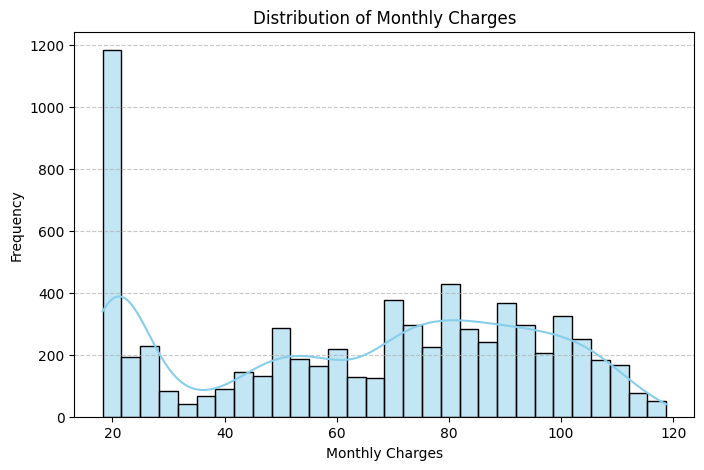

In [122]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], kde=True, bins=30, color='skyblue')
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### B. Tenure Distribution

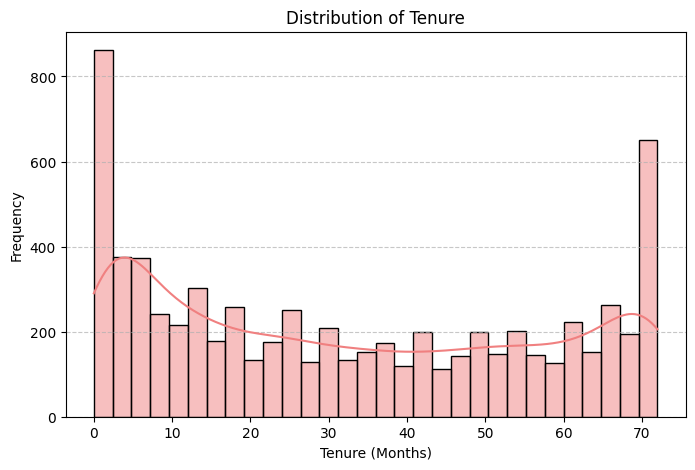

In [123]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], kde=True, bins=30, color='lightcoral')
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### C. Total Charges Distribution

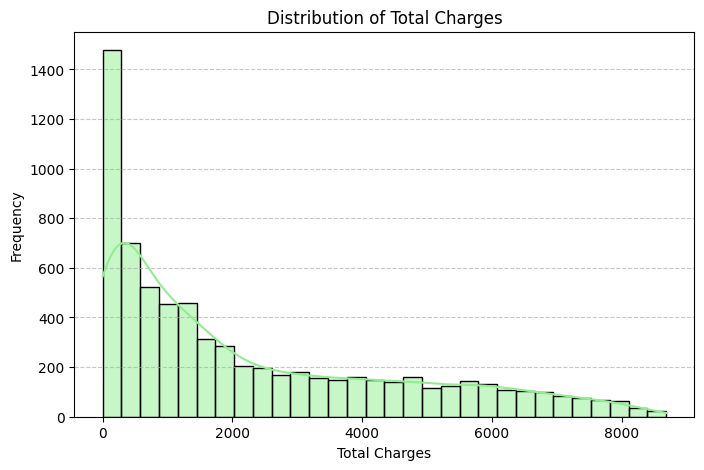

In [124]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalCharges"], kde=True, bins=30, color='lightgreen')
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### D. Senior Citizen Distribution

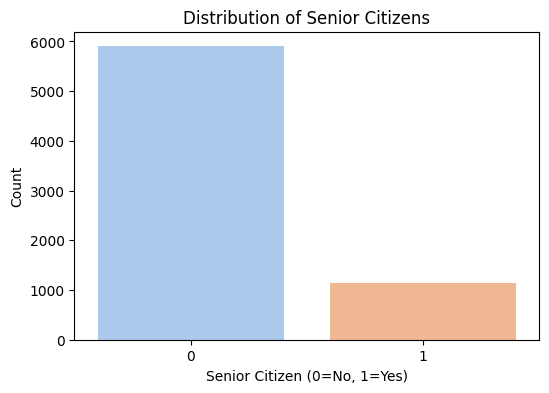

,proportion
SeniorCitizen,
0,83.785319
1,16.214681


In [125]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", data=df, palette='pastel')
plt.title("Distribution of Senior Citizens")
plt.xlabel("Senior Citizen (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

display(df["SeniorCitizen"].value_counts(normalize=True) * 100)

#### E. Categorical Feature Distributions

Let's examine the distribution of some key categorical features to understand their composition within the dataset.

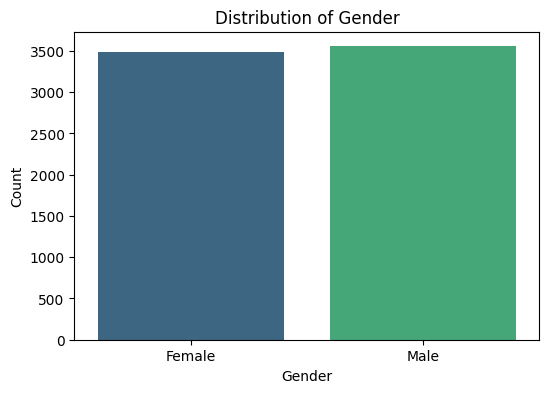

,proportion
gender,
Male,50.47565
Female,49.52435


In [126]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df, palette='viridis')
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()
display(df["gender"].value_counts(normalize=True) * 100)

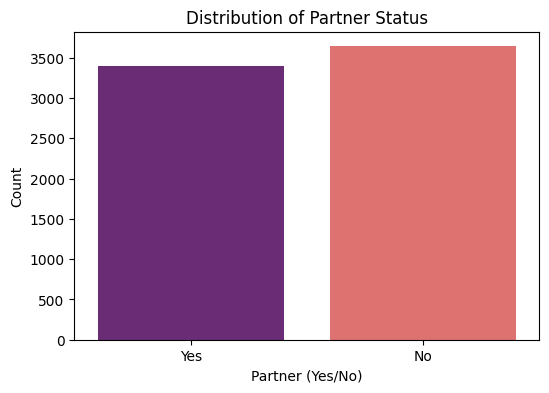

,proportion
Partner,
No,51.69672
Yes,48.30328


In [127]:
plt.figure(figsize=(6,4))
sns.countplot(x="Partner", data=df, palette='magma')
plt.title("Distribution of Partner Status")
plt.xlabel("Partner (Yes/No)")
plt.ylabel("Count")
plt.show()
display(df["Partner"].value_counts(normalize=True) * 100)

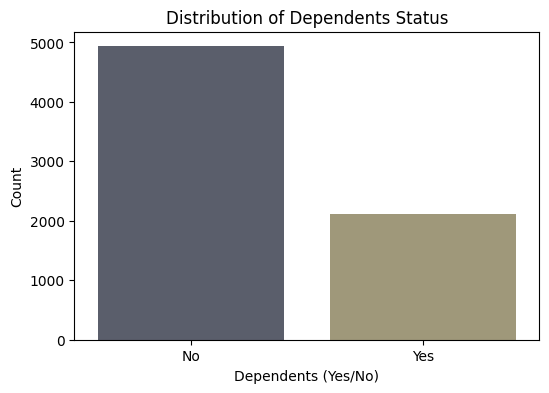

,proportion
Dependents,
No,70.041176
Yes,29.958824


In [128]:
plt.figure(figsize=(6,4))
sns.countplot(x="Dependents", data=df, palette='cividis')
plt.title("Distribution of Dependents Status")
plt.xlabel("Dependents (Yes/No)")
plt.ylabel("Count")
plt.show()
display(df["Dependents"].value_counts(normalize=True) * 100)

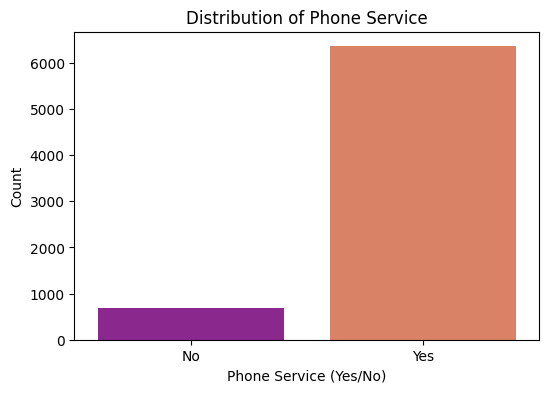

,proportion
PhoneService,
Yes,90.316626
No,9.683374


In [129]:
plt.figure(figsize=(6,4))
sns.countplot(x="PhoneService", data=df, palette='plasma')
plt.title("Distribution of Phone Service")
plt.xlabel("Phone Service (Yes/No)")
plt.ylabel("Count")
plt.show()
display(df["PhoneService"].value_counts(normalize=True) * 100)

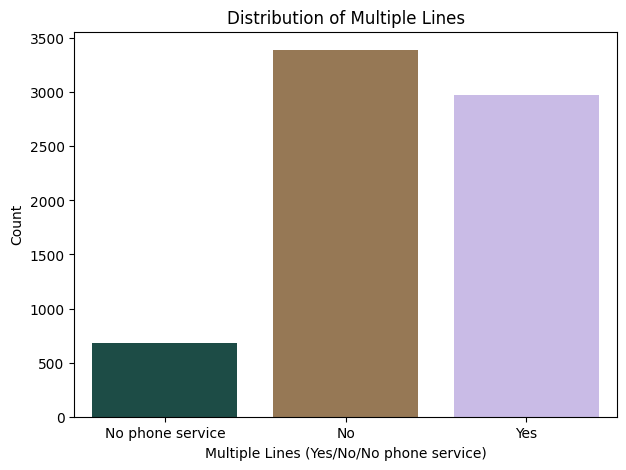

,proportion
MultipleLines,
No,48.132898
Yes,42.183729
No phone service,9.683374


In [130]:
plt.figure(figsize=(7,5))
sns.countplot(x="MultipleLines", data=df, palette='cubehelix')
plt.title("Distribution of Multiple Lines")
plt.xlabel("Multiple Lines (Yes/No/No phone service)")
plt.ylabel("Count")
plt.show()
display(df["MultipleLines"].value_counts(normalize=True) * 100)

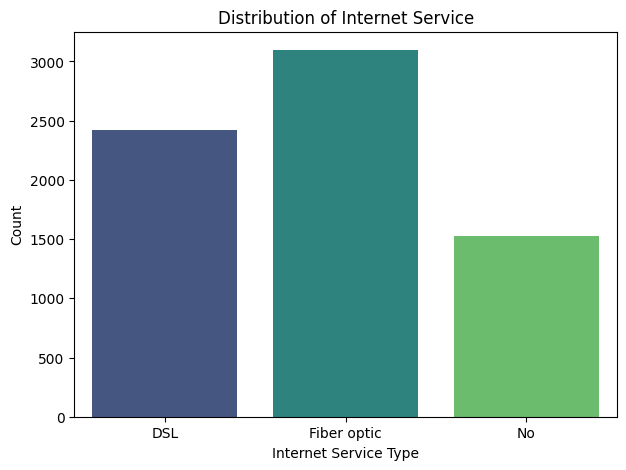

,proportion
InternetService,
Fiber optic,43.958540
DSL,34.374556
No,21.666903


In [131]:
plt.figure(figsize=(7,5))
sns.countplot(x="InternetService", data=df, palette='viridis')
plt.title("Distribution of Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Count")
plt.show()
display(df["InternetService"].value_counts(normalize=True) * 100)

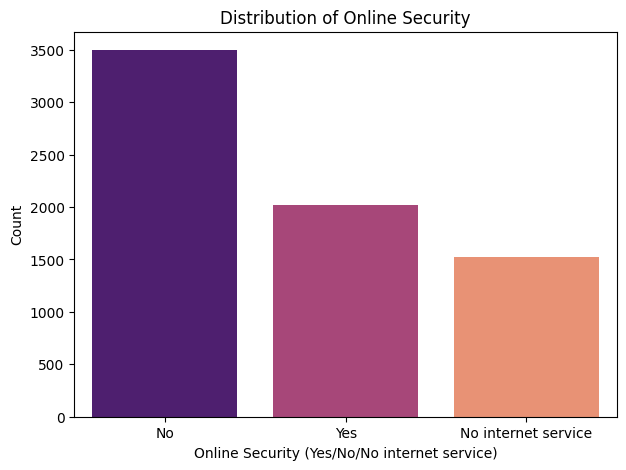

,proportion
OnlineSecurity,
No,49.666335
Yes,28.666761
No internet service,21.666903


In [132]:
plt.figure(figsize=(7,5))
sns.countplot(x="OnlineSecurity", data=df, palette='magma')
plt.title("Distribution of Online Security")
plt.xlabel("Online Security (Yes/No/No internet service)")
plt.ylabel("Count")
plt.show()
display(df["OnlineSecurity"].value_counts(normalize=True) * 100)

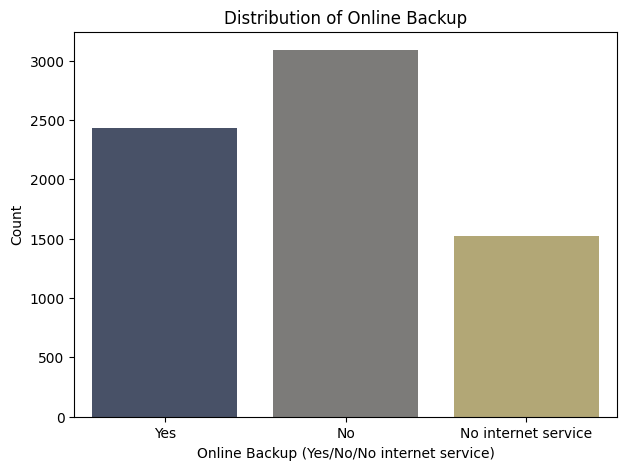

,proportion
OnlineBackup,
No,43.844952
Yes,34.488144
No internet service,21.666903


In [133]:
plt.figure(figsize=(7,5))
sns.countplot(x="OnlineBackup", data=df, palette='cividis')
plt.title("Distribution of Online Backup")
plt.xlabel("Online Backup (Yes/No/No internet service)")
plt.ylabel("Count")
plt.show()
display(df["OnlineBackup"].value_counts(normalize=True) * 100)

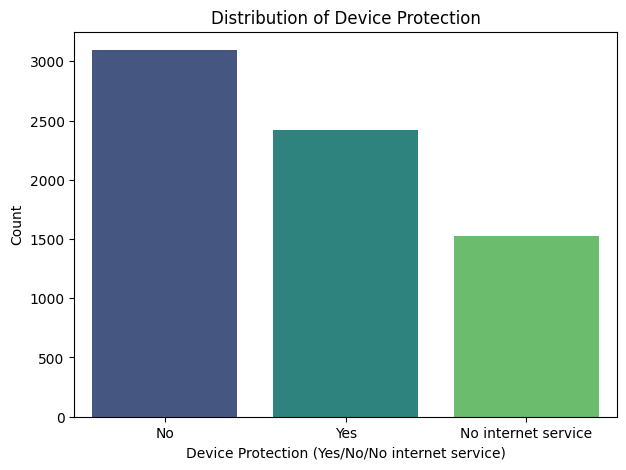

,proportion
DeviceProtection,
No,43.944342
Yes,34.388755
No internet service,21.666903


In [134]:
plt.figure(figsize=(7,5))
sns.countplot(x="DeviceProtection", data=df, palette='viridis')
plt.title("Distribution of Device Protection")
plt.xlabel("Device Protection (Yes/No/No internet service)")
plt.ylabel("Count")
plt.show()
display(df["DeviceProtection"].value_counts(normalize=True) * 100)

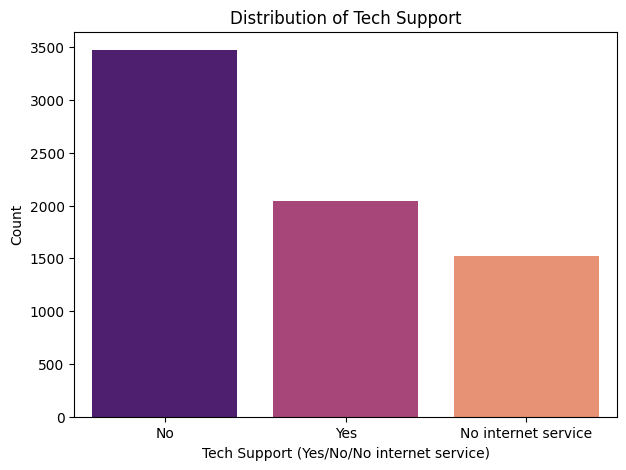

,proportion
TechSupport,
No,49.311373
Yes,29.021724
No internet service,21.666903


In [135]:
plt.figure(figsize=(7,5))
sns.countplot(x="TechSupport", data=df, palette='magma')
plt.title("Distribution of Tech Support")
plt.xlabel("Tech Support (Yes/No/No internet service)")
plt.ylabel("Count")
plt.show()
display(df["TechSupport"].value_counts(normalize=True) * 100)

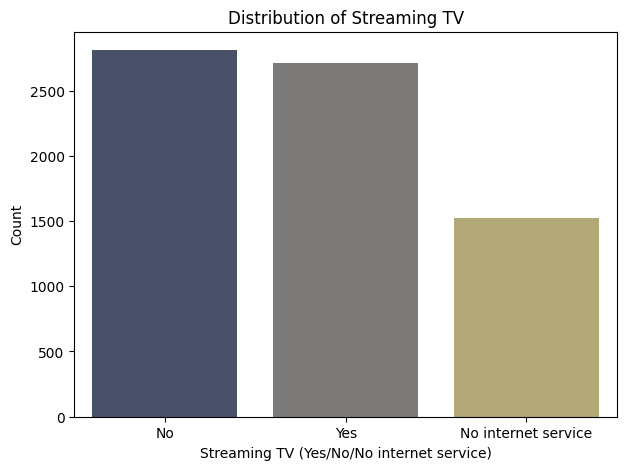

,proportion
StreamingTV,
No,39.897771
Yes,38.435326
No internet service,21.666903


In [136]:
plt.figure(figsize=(7,5))
sns.countplot(x="StreamingTV", data=df, palette='cividis')
plt.title("Distribution of Streaming TV")
plt.xlabel("Streaming TV (Yes/No/No internet service)")
plt.ylabel("Count")
plt.show()
display(df["StreamingTV"].value_counts(normalize=True) * 100)

#### D. Churn Rate by Tenure

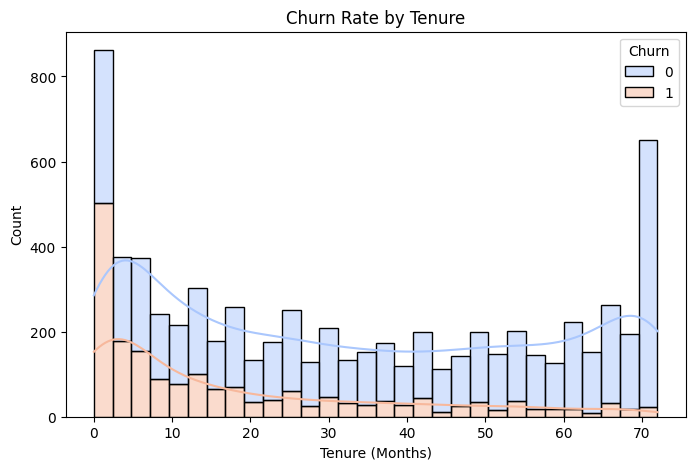

In [137]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, kde=True, palette='coolwarm')
plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

#### E. Churn Rate by Monthly Charges

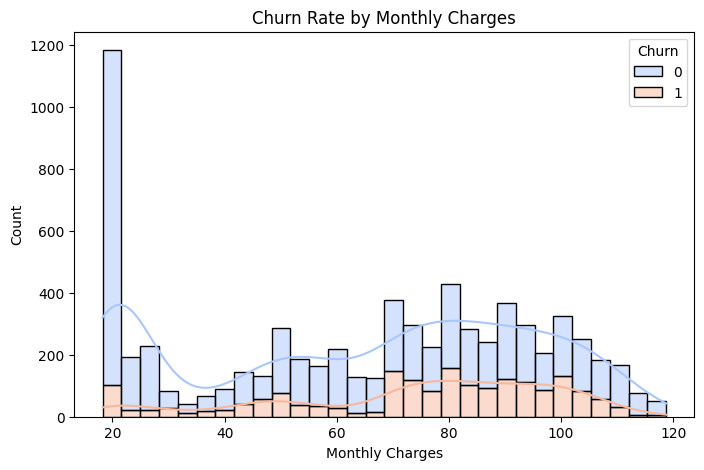

In [88]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30, kde=True, palette='coolwarm')
plt.title('Churn Rate by Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.show()

#### F. Churn Rate by Total Charges

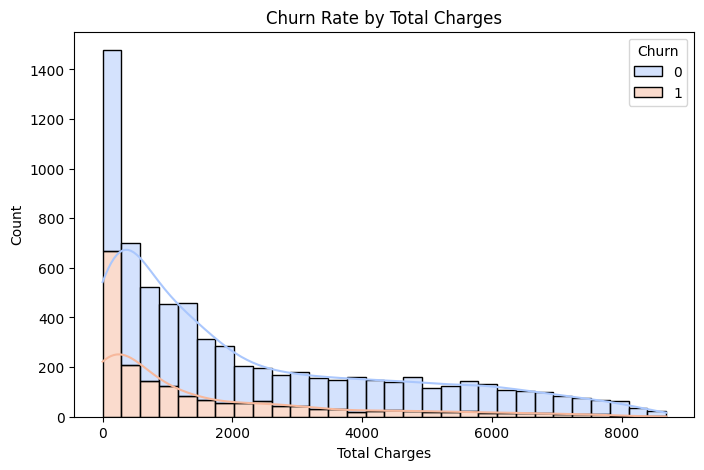

In [89]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='TotalCharges', hue='Churn', multiple='stack', bins=30, kde=True, palette='coolwarm')
plt.title('Churn Rate by Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Count')
plt.show()

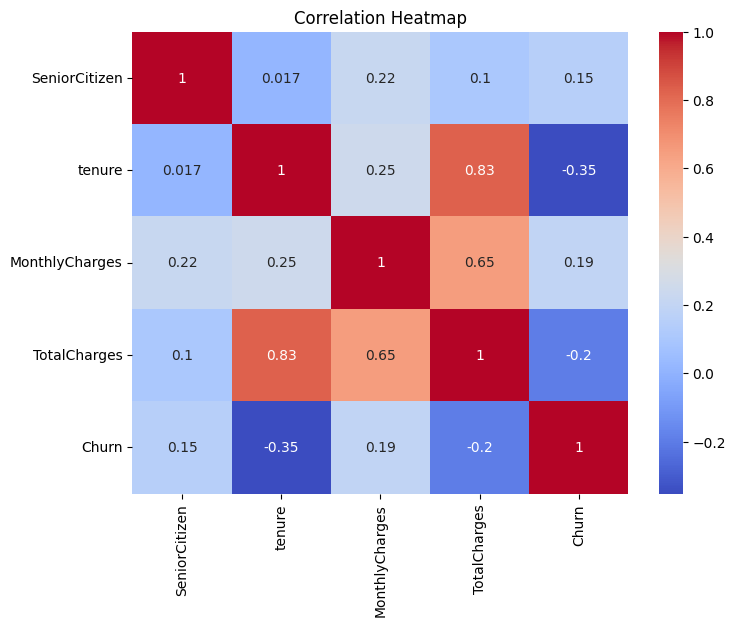

In [90]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges","Churn"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

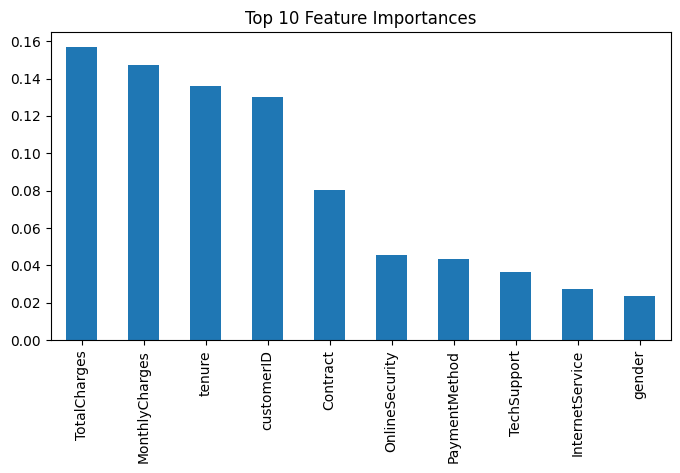

In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Temporary encoding for feature importance only
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X_temp = df_encoded.drop("Churn", axis=1)
y_temp = df_encoded["Churn"]

rf_temp = RandomForestClassifier()
rf_temp.fit(X_temp, y_temp)

importances = pd.Series(rf_temp.feature_importances_, index=X_temp.columns)
importances.sort_values(ascending=False).head(10).plot(kind="bar", figsize=(8,4))
plt.title("Top 10 Feature Importances")
plt.show()

#### H. Data Preprocessing Pipeline
Now, let's establish a robust preprocessing pipeline for our data. This involves defining transformers for numerical and categorical features, combining them using a `ColumnTransformer`, performing a stratified train-test split, and addressing class imbalance with SMOTE.

In [92]:
# Define preprocessing steps for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a ColumnTransformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Preprocessing pipeline for numerical and categorical features defined.")

Preprocessing pipeline for numerical and categorical features defined.


### A. Train-Test Split

We'll split the data into training and testing sets (80% train, 20% test) to evaluate model performance on unseen data. Stratified sampling will be used to maintain the proportion of churned customers in both sets.

In [93]:
# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Check the distribution of the target variable in train and test sets
print("\nChurn distribution in training set:")
display(y_train.value_counts(normalize=True))
print("\nChurn distribution in test set:")
display(y_test.value_counts(normalize=True))

X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)

Churn distribution in training set:


,proportion
Churn,
0,0.734647
1,0.265353



Churn distribution in test set:


,proportion
Churn,
0,0.734564
1,0.265436


### B. Apply Preprocessing and SMOTE

We will now apply the defined preprocessing steps (scaling numerical features and one-hot encoding categorical features) to our training and testing data. Due to the class imbalance observed in the 'Churn' variable, we will use SMOTE (Synthetic Minority Over-sampling Technique) on the *training data only* to create synthetic samples of the minority class, ensuring our models don't become biased towards the majority class.

In [94]:
# Apply preprocessing to training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape of preprocessed X_train: {X_train_processed.shape}")
print(f"Shape of preprocessed X_test: {X_test_processed.shape}")

# Apply SMOTE to the processed training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print(f"Shape of X_train after SMOTE: {X_train_resampled.shape}")
print(f"Shape of y_train after SMOTE: {y_train_resampled.shape}")

print("\nChurn distribution in training set after SMOTE:")
display(y_train_resampled.value_counts(normalize=True))

Shape of preprocessed X_train: (5634, 45)
Shape of preprocessed X_test: (1409, 45)
Shape of X_train after SMOTE: (8278, 45)
Shape of y_train after SMOTE: (8278,)

Churn distribution in training set after SMOTE:


,proportion
Churn,
0,0.5
1,0.5


### C. Model Implementation and Evaluation

We will implement the specified machine learning models, train them on the preprocessed and resampled training data, and evaluate their performance on the preprocessed test data. For each model, we'll calculate Accuracy, Precision, Recall, F1 Score, and ROC-AUC Score. We'll also display the confusion matrix.

In [95]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), # eval_metric added to suppress warning
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, random_state=42) # probability=True for ROC-AUC
}

# Store results
results = []

# Function to train and evaluate a model
def evaluate_model(name, model, X_train_resampled, y_train_resampled, X_test_processed, y_test):
    print(f"\n--- {name} ---")
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC: {roc_auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Normalized Confusion Matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("\nNormalized Confusion Matrix:")
    print(cm_normalized)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Loop through models and evaluate
for name, model in models.items():
    model_results = evaluate_model(name, model, X_train_resampled, y_train_resampled, X_test_processed, y_test)
    results.append(model_results)

# Create a DataFrame for comparison
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='ROC-AUC', ascending=False))


--- Logistic Regression ---
Accuracy: 0.7374
Precision: 0.5034
Recall: 0.7941
F1 Score: 0.6162
ROC-AUC: 0.8403

Confusion Matrix:
[[742 293]
 [ 77 297]]

Normalized Confusion Matrix:
[[0.71690821 0.28309179]
 [0.20588235 0.79411765]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


--- Decision Tree ---
Accuracy: 0.7161
Precision: 0.4693
Recall: 0.5321
F1 Score: 0.4987
ROC-AUC: 0.6571

Confusion Matrix:
[[810 225]
 [175 199]]

Normalized Confusion Matrix:
[[0.7826087  0.2173913 ]
 [0.46791444 0.53208556]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1035
           1       0.47      0.53      0.50       37

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Gradient Boosting,0.772179,0.558499,0.676471,0.611850,0.840701
0,Logistic Regression,0.737402,0.503390,0.794118,0.616183,0.840272
6,SVM,0.754436,0.527344,0.721925,0.609481,0.821163
4,XGBoost,0.782115,0.587467,0.601604,0.594452,0.817319
2,Random Forest,0.769340,0.567493,0.550802,0.559023,0.814672
5,KNN,0.694109,0.451115,0.703209,0.549634,0.768006
1,Decision Tree,0.716111,0.469340,0.532086,0.498747,0.657121


### A. Accuracy Comparison Bar Chart

This chart visualizes the accuracy scores of all trained models, allowing for a quick comparison of their overall correctness.

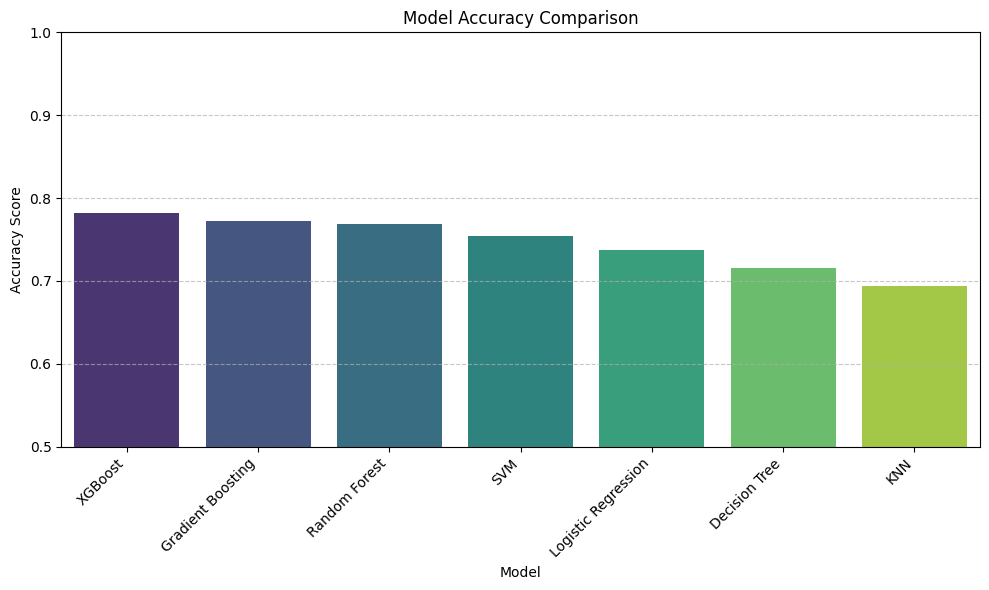

In [96]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df.sort_values(by='Accuracy', ascending=False), palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.5, 1.0) # Set a reasonable y-limit for classification accuracy
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation:

*   **Best Performing Model:** Identify the model with the highest accuracy score.
*   **Overall Correctness:** Accuracy measures the proportion of correctly classified instances (both churned and non-churned).
*   **Business Impact:** High accuracy is desirable, but for imbalanced datasets, other metrics like precision and recall might be more informative for business decisions related to churn, as a model can have high accuracy by simply predicting the majority class.

### B. Precision Comparison Bar Chart

This chart compares the precision scores of each model, highlighting their ability to correctly identify actual churners among all instances predicted as churners.

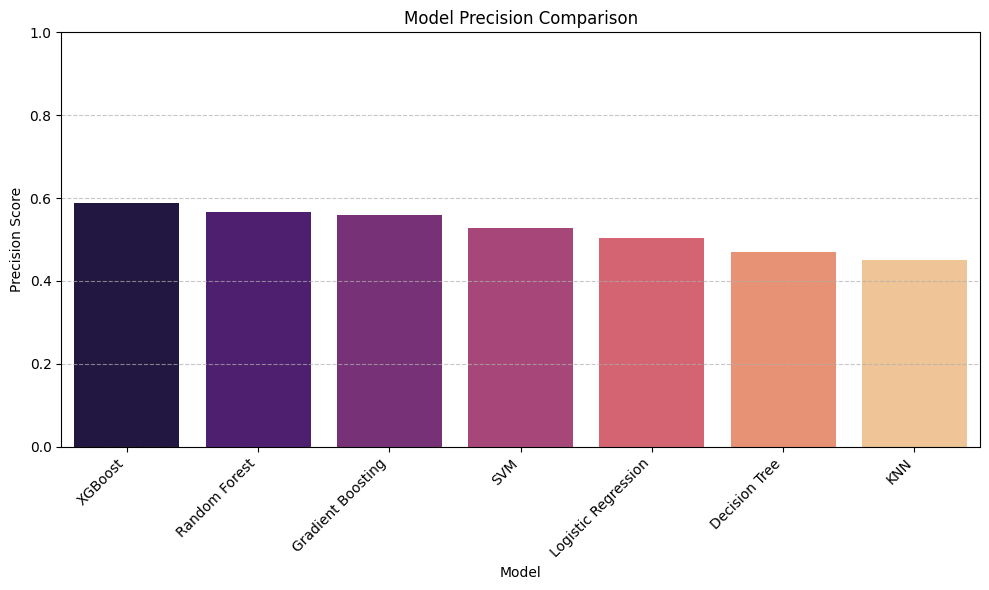

In [97]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Precision', data=results_df.sort_values(by='Precision', ascending=False), palette='magma')
plt.title('Model Precision Comparison')
plt.ylabel('Precision Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.0, 1.0) # Precision can be lower
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation:

*   **Best Performing Model:** Identify the model with the highest precision score.
*   **Precision Definition:** Precision is the ratio of true positives to the sum of true positives and false positives. It answers the question: "Of all customers predicted to churn, how many actually churned?"
*   **Business Impact (Minimizing False Positives):** High precision is crucial when the cost of a false positive is high. For example, if offering retention incentives to a customer who was incorrectly predicted to churn is expensive, a model with higher precision would be preferred to avoid wasting resources.

### C. Recall Comparison Bar Chart

This chart illustrates the recall scores of the models, showing their effectiveness in identifying all actual churners in the dataset.

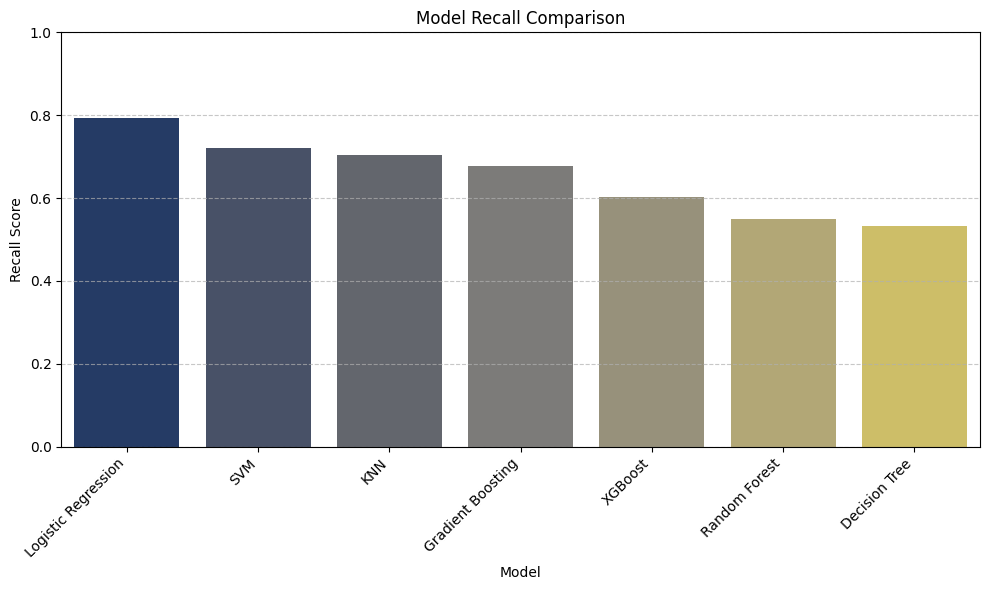

In [98]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Recall', data=results_df.sort_values(by='Recall', ascending=False), palette='cividis')
plt.title('Model Recall Comparison')
plt.ylabel('Recall Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.0, 1.0) # Recall can be lower
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation:

*   **Best Performing Model:** Identify the model with the highest recall score.
*   **Recall Definition:** Recall (also known as sensitivity) is the ratio of true positives to the sum of true positives and false negatives. It answers the question: "Of all customers who actually churned, how many did the model correctly identify?"
*   **Business Impact (Minimizing False Negatives):** High recall is vital when the cost of a false negative is high. In churn prediction, failing to identify a customer who will churn (false negative) means losing that customer. Therefore, a model with higher recall is often preferred to maximize the chances of retaining at-risk customers, even if it means some false positives.

### D. F1 Score Comparison Bar Chart

The F1 Score provides a balance between precision and recall, especially useful when there is an uneven class distribution. This chart displays the F1 scores for each model.

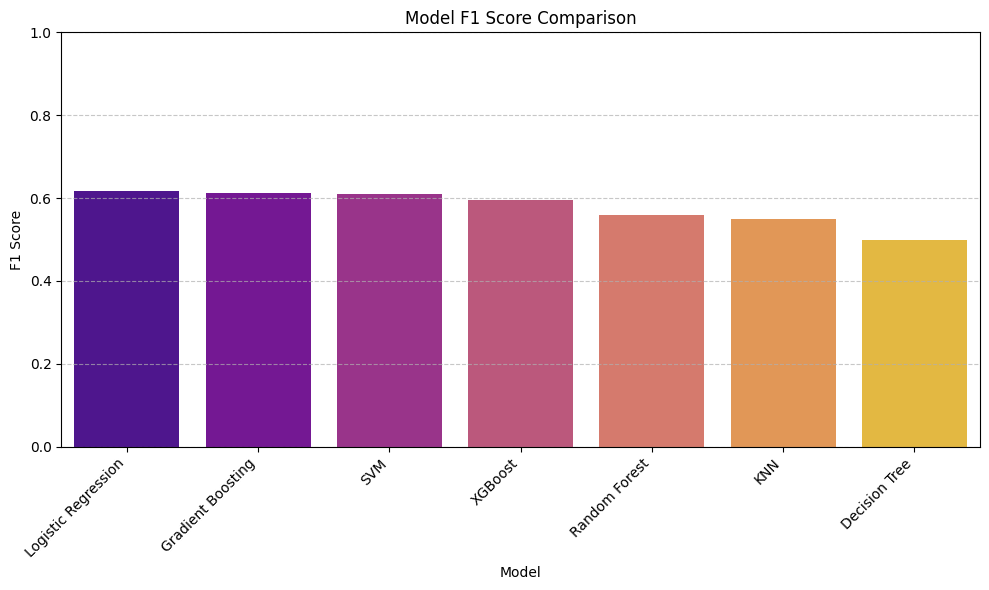

In [99]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1-Score', data=results_df.sort_values(by='F1-Score', ascending=False), palette='plasma')
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation:

*   **Best Performing Model:** Identify the model with the highest F1 Score.
*   **F1 Score Definition:** The F1 Score is the harmonic mean of precision and recall. It's a good metric to use when you need to balance both precision and recall, especially in cases of imbalanced classes.
*   **Business Impact (Balanced Performance):** A high F1 Score indicates that the model is performing well across both identifying churners correctly (precision) and finding most of the actual churners (recall). This is often a preferred metric when both types of errors (false positives and false negatives) have significant, but perhaps different, costs.

### E. ROC-AUC Comparison Bar Chart

The ROC-AUC score measures the area under the Receiver Operating Characteristic curve, indicating the model's ability to distinguish between churners and non-churners across all possible classification thresholds.

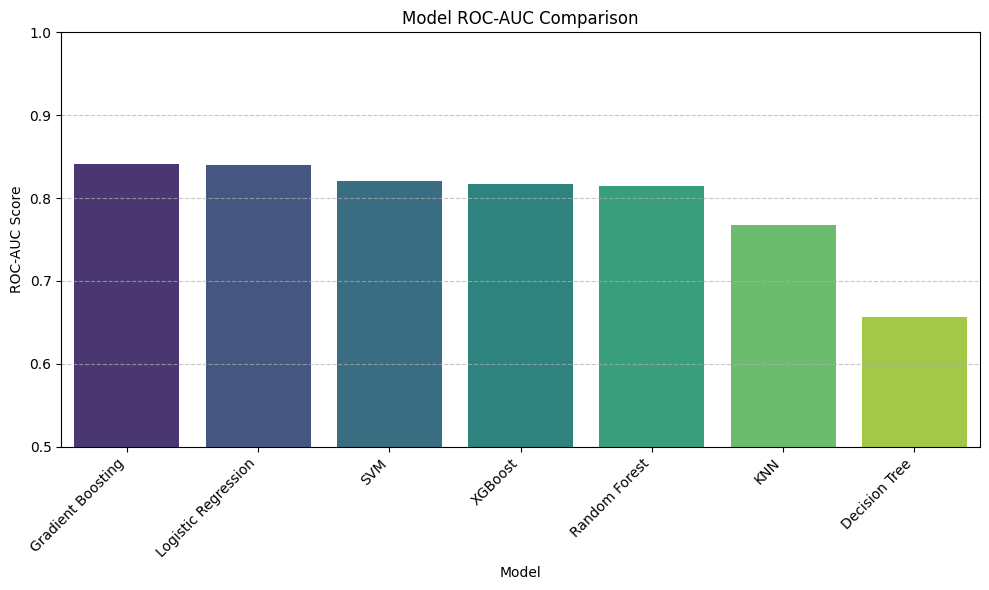

In [100]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ROC-AUC', data=results_df.sort_values(by='ROC-AUC', ascending=False), palette='viridis')
plt.title('Model ROC-AUC Comparison')
plt.ylabel('ROC-AUC Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.5, 1.0) # ROC-AUC scores typically range from 0.5 (random) to 1.0 (perfect)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation:

*   **Best Performing Model:** Identify the model with the highest ROC-AUC score.
*   **ROC-AUC Definition:** The Area Under the Receiver Operating Characteristic Curve (ROC-AUC) quantifies a model's ability to discriminate between positive and negative classes. A higher ROC-AUC indicates a better ability to distinguish between churners and non-churners.
*   **Business Impact (Discriminative Power):** A high ROC-AUC suggests that the model is robust in its predictions, regardless of the chosen classification threshold. This is important when the business needs flexibility in setting thresholds (e.g., to be more aggressive in identifying potential churners at certain times).

### F. Combined ROC Curve

This visualization plots the ROC curves for all models on a single graph, allowing for a comprehensive comparison of their true positive rate vs. false positive rate across different thresholds.

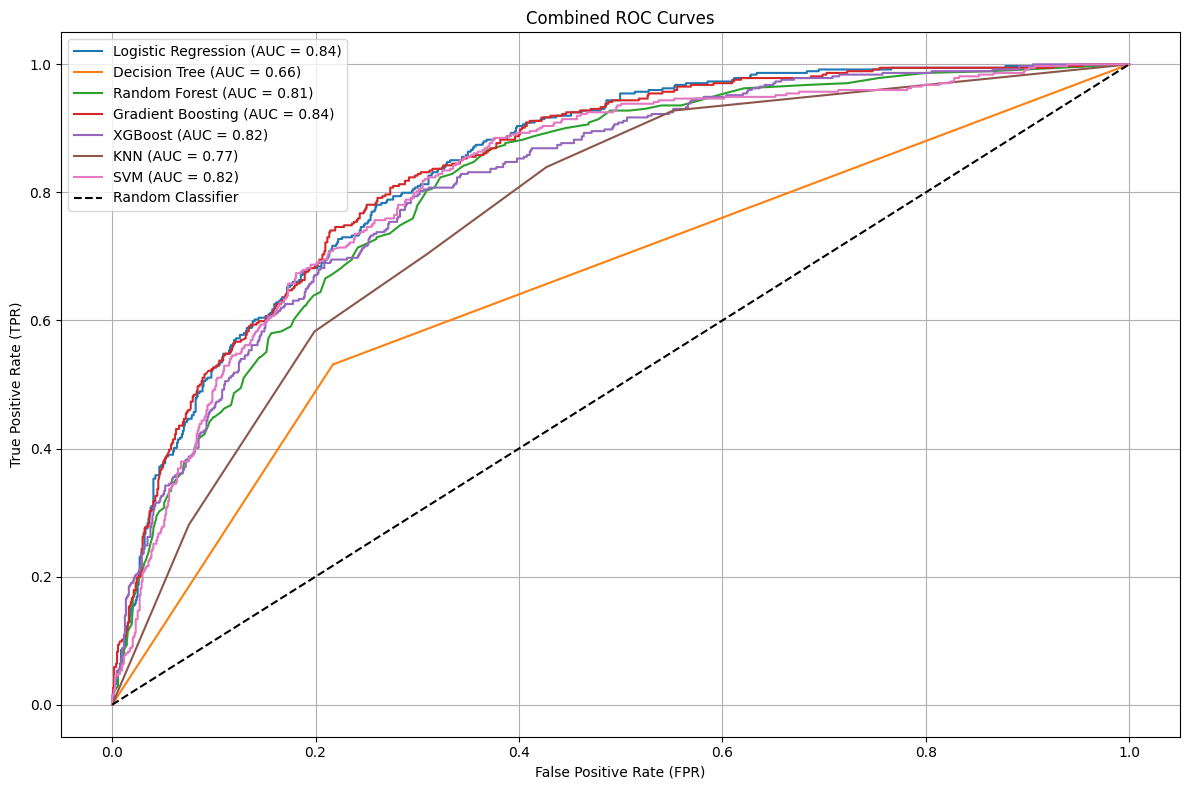

In [101]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(12, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_processed)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
    else: # For models like SVM without direct predict_proba, if probability=True is not set
        print(f"Warning: {name} does not support predict_proba and cannot be plotted on ROC curve.")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Combined ROC Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretation:

*   **Visual Comparison:** The closer a curve is to the top-left corner, the better its performance. The diagonal dashed line represents a random classifier.
*   **Best Performing Model:** The model with the curve closest to the top-left corner and the highest AUC score generally has the best overall discriminative power.
*   **Business Impact:** ROC curves help in understanding the trade-off between identifying true churners and incorrectly identifying non-churners across various thresholds. This is valuable for strategic decision-making where different error types might have different costs or implications.

### G. Precision-Recall Curves

Precision-Recall curves are particularly informative for imbalanced datasets, as they focus on the performance of the minority class. This plot compares the precision-recall trade-off for all models.

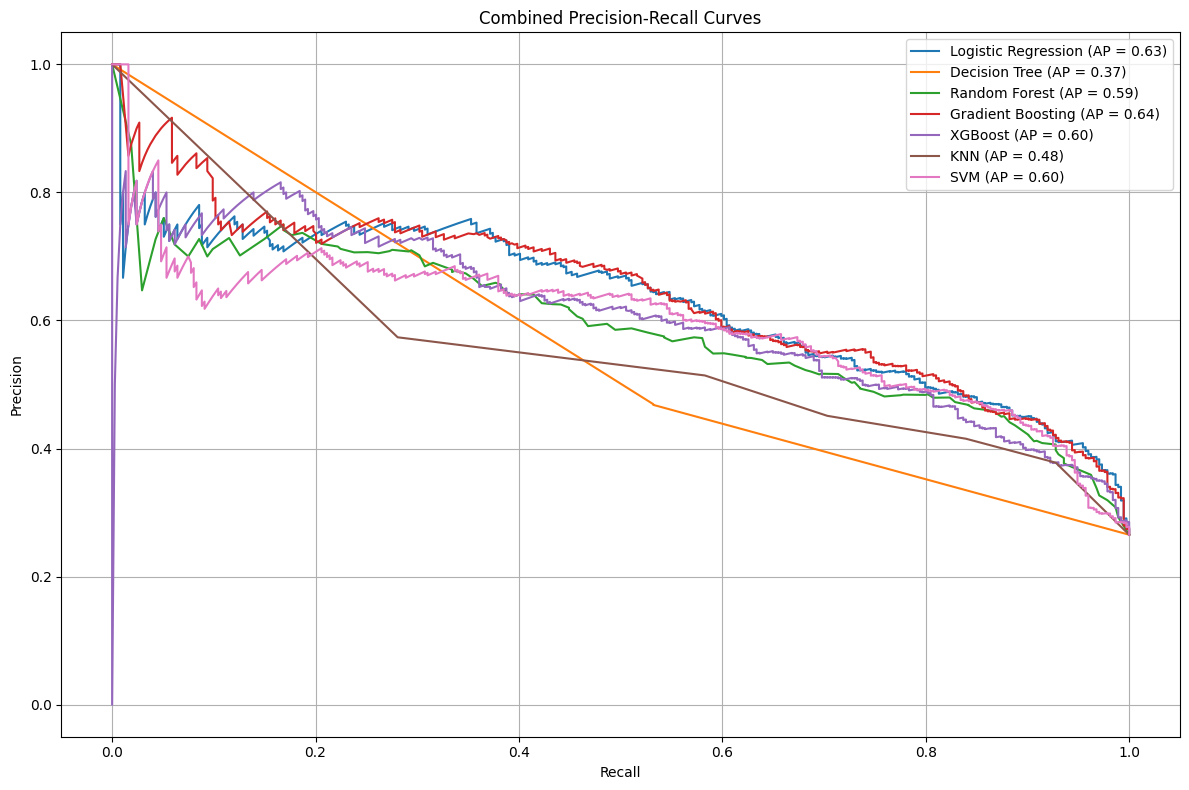

In [102]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(12, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_processed)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        avg_precision = average_precision_score(y_test, y_proba)
        plt.plot(recall, precision, label=f'{name} (AP = {avg_precision:.2f})')
    else:
        print(f"Warning: {name} does not support predict_proba and cannot be plotted on Precision-Recall curve.")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Combined Precision-Recall Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretation:

*   **Visual Comparison:** A curve closer to the top-right corner indicates better performance. The Average Precision (AP) score summarizes the curve.
*   **Best Performing Model:** The model with the highest Average Precision score and the curve that encompasses a larger area toward the top-right is generally preferred, especially for identifying churners.
*   **Business Impact:** Precision-Recall curves are critical in churn prediction because identifying churners (the positive class) is often the primary goal, and this plot provides a clear view of how well models perform in this specific task, without being influenced by the large number of non-churners. It helps in deciding if a model's performance on the churn class is acceptable.

### H. Confusion Matrix Grid

This section displays the confusion matrices for all models in a grid format, providing a detailed breakdown of true positives, true negatives, false positives, and false negatives for each model.

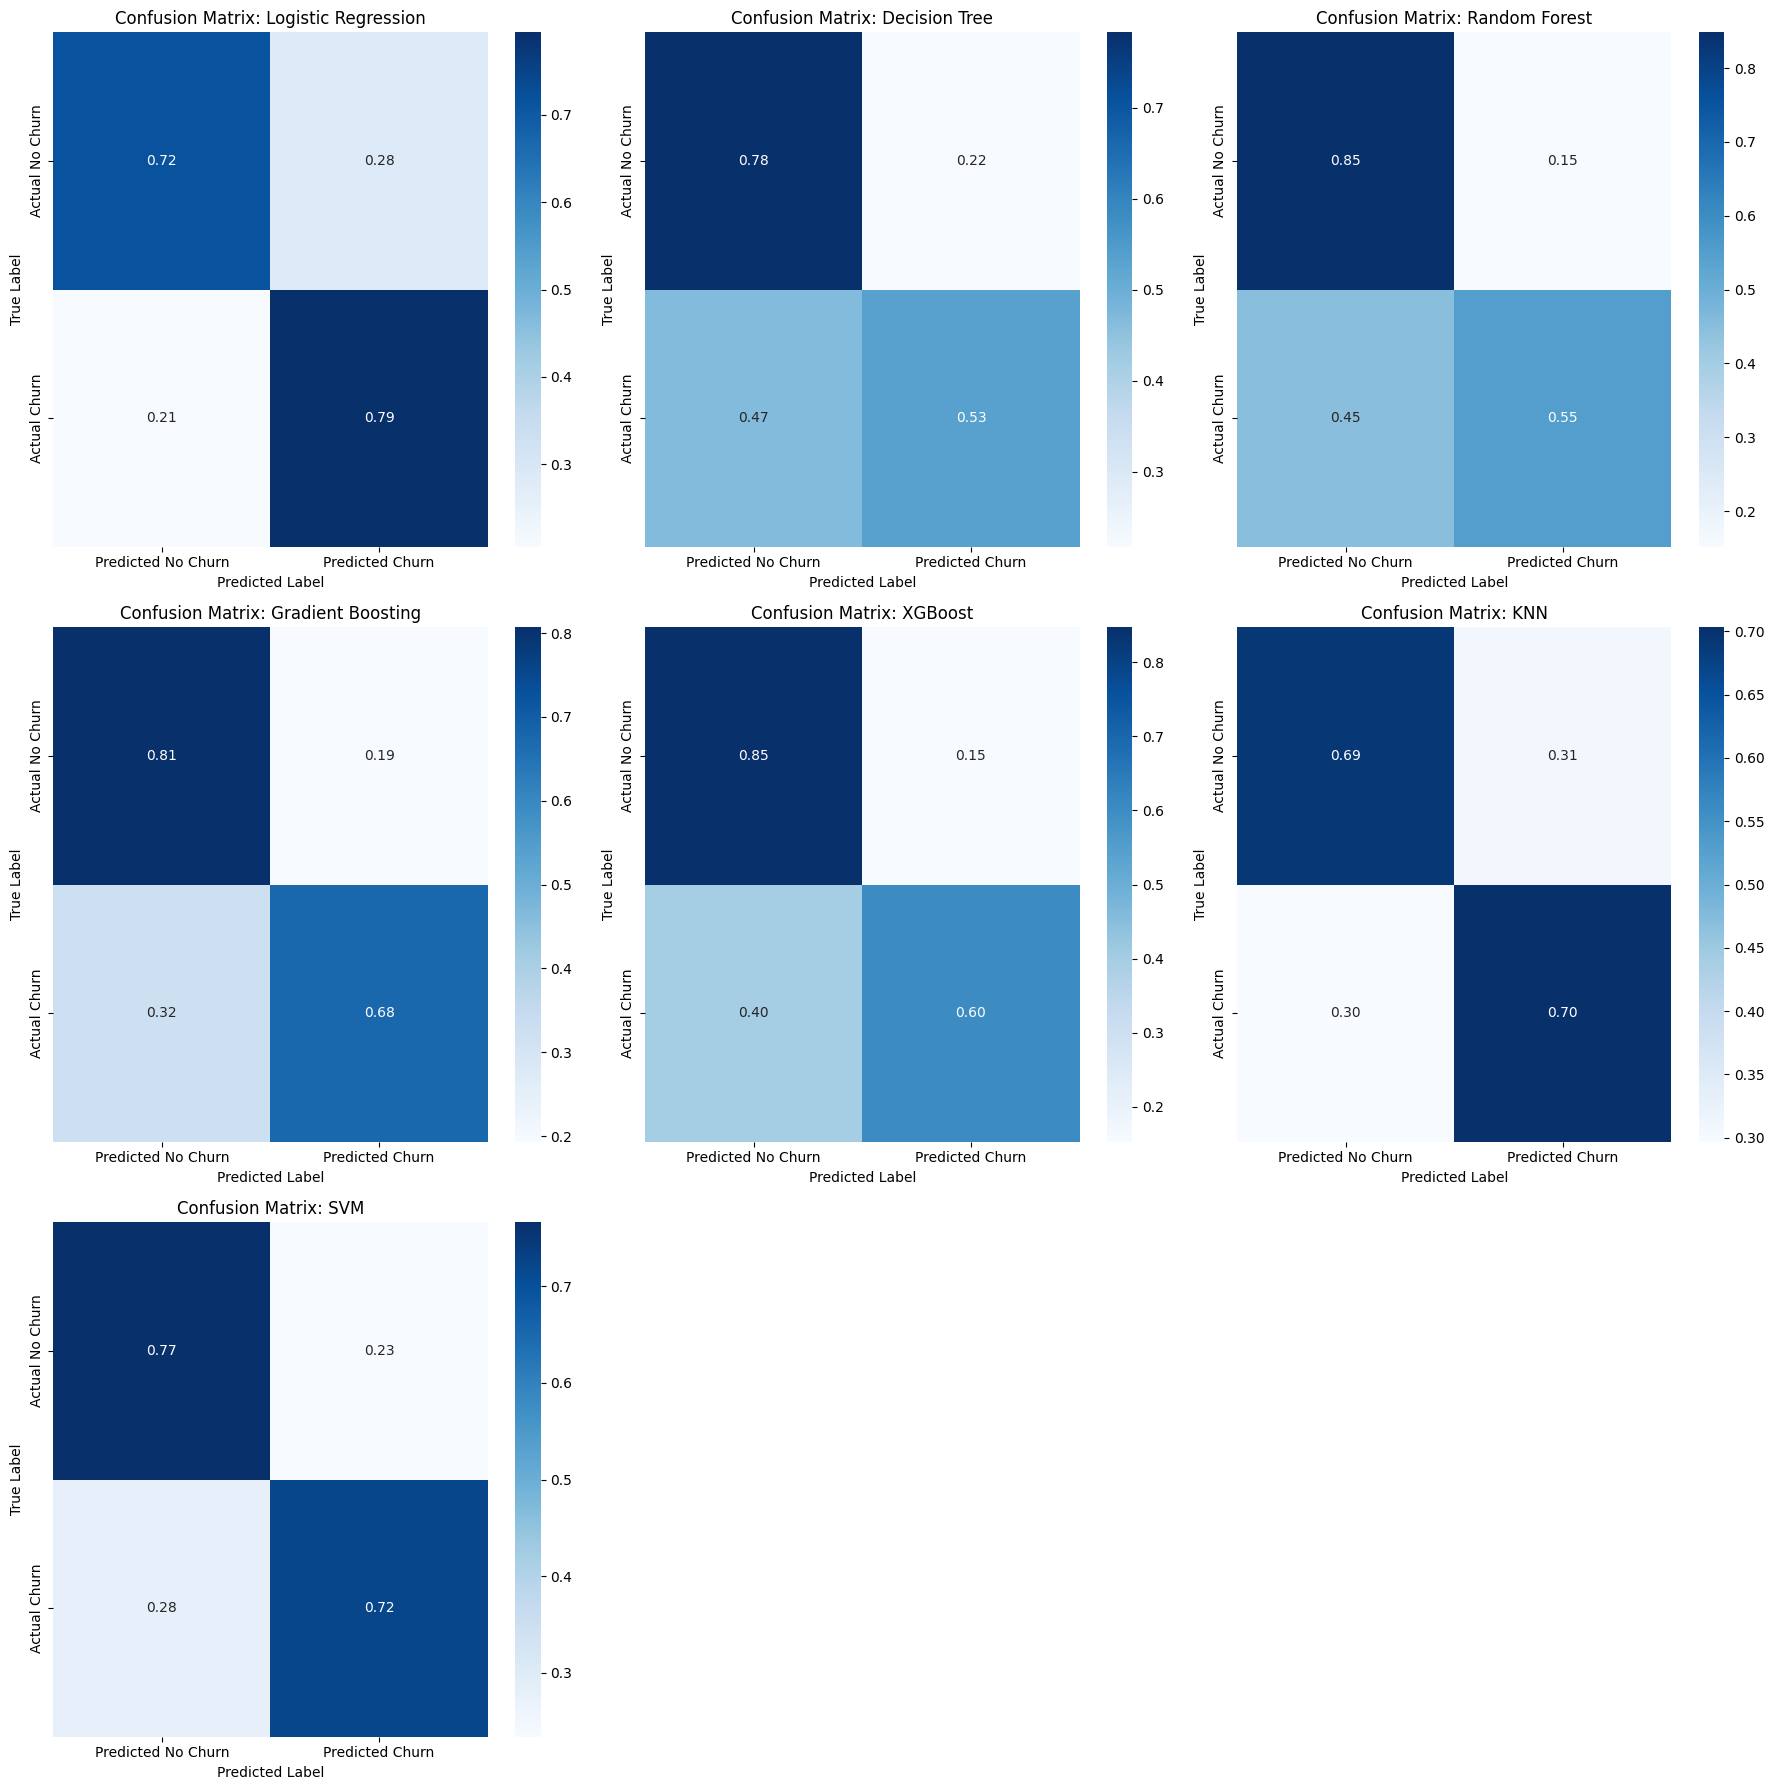

In [103]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18)) # Changed to 3x3 grid to accommodate 7 models
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    # Only plot if there is an axis available
    if i < len(axes):
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test_processed)
        cm = confusion_matrix(y_test, y_pred)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize for better comparison

        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[i],
                    xticklabels=['Predicted No Churn', 'Predicted Churn'],
                    yticklabels=['Actual No Churn', 'Actual Churn'])
        axes[i].set_title(f'Confusion Matrix: {name}')
        axes[i].set_xlabel('Predicted Label')
        axes[i].set_ylabel('True Label')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Interpretation:

*   **Visual Comparison:** Each confusion matrix shows the percentage of correctly and incorrectly classified instances for each class. Focus on the 'Actual Churn' row to see the recall (True Positives percentage) and 'Predicted Churn' column to see the precision (True Positives percentage).
*   **Recall Comparison:** Look at the bottom-left value (False Negatives) and bottom-right value (True Positives) in the normalized matrices. A higher True Positive rate (bottom-right) indicates better recall for the churn class.
*   **Precision Comparison:** Look at the top-right value (False Positives) and bottom-right value (True Positives). A lower False Positive rate (top-right) and higher True Positive rate for the 'Predicted Churn' column indicates better precision for the churn class.
*   **Business Impact:** Confusion matrices provide a granular view of the types of errors each model makes. For churn prediction, it's crucial to understand the trade-off between false positives (predicting churn when a customer won't, potentially leading to unnecessary intervention costs) and false negatives (failing to predict churn when a customer will, leading to lost customers). The ideal balance depends on the specific business strategy and the costs associated with each error type.

### I. Random Forest Feature Importance

Feature importance from the Random Forest model helps us understand which features contribute most to its predictions. This insight can be valuable for business strategy, allowing focus on key drivers of churn.

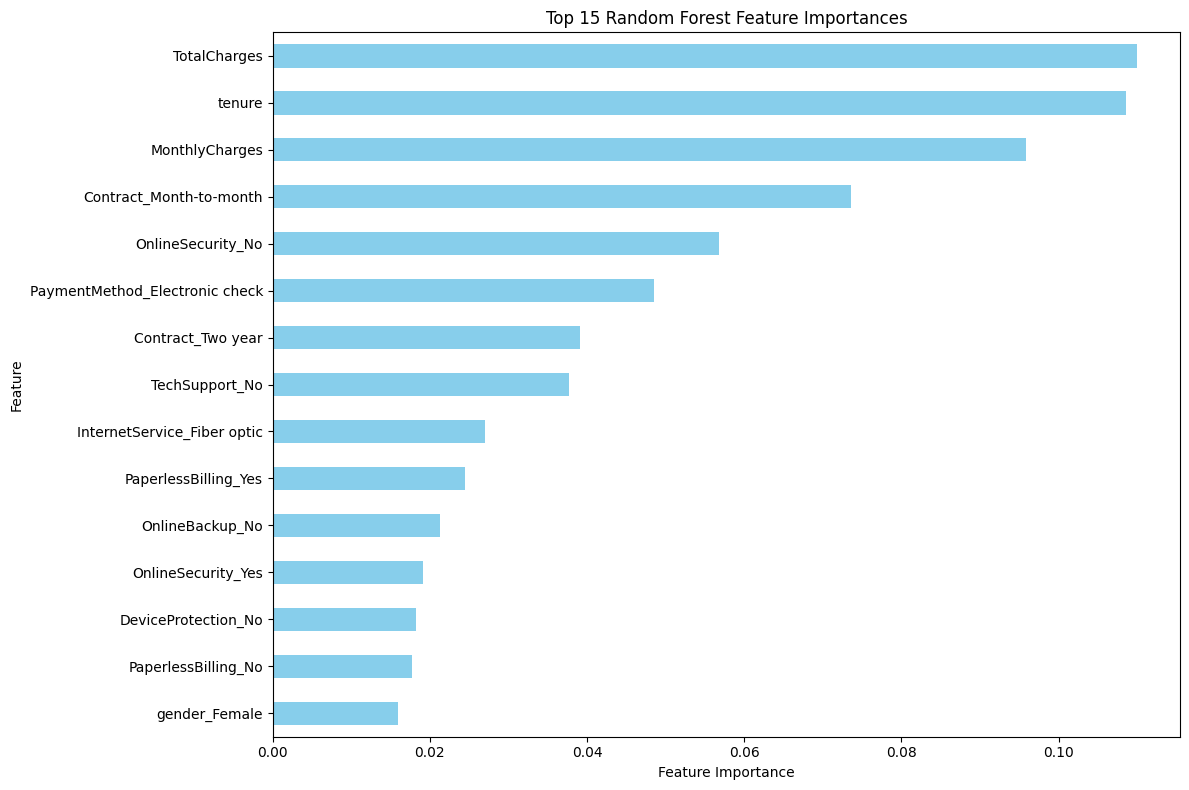

In [104]:
# Re-train Random Forest on processed data to get feature importances
rf_model = models['Random Forest']
rf_model.fit(X_train_resampled, y_train_resampled)

# Get feature names after one-hot encoding
categorical_features_encoded = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_features = list(numerical_cols) + list(categorical_features_encoded)

# Get importances
importances = pd.Series(rf_model.feature_importances_, index=all_features)

plt.figure(figsize=(12, 8))
importances.sort_values(ascending=False).head(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()
plt.show()

#### Interpretation:

*   **Best Performing Model's Drivers:** This plot reveals the most influential features according to the Random Forest model. Features with higher importance scores have a greater impact on the model's prediction of customer churn.
*   **Key Churn Factors:** Identify which customer attributes or service aspects are most strongly associated with churn.
*   **Business Impact:** Understanding these key features is invaluable for designing targeted retention strategies. For instance, if 'Contract_Month-to-month' is a high-importance feature, it indicates that customers on monthly contracts are more likely to churn, prompting the business to offer incentives for longer-term commitments. Similarly, high importance for 'InternetService_Fiber optic' might suggest issues with that service type.

### J. XGBoost Feature Importance

Similarly, XGBoost also provides feature importance, which can offer additional insights into the most predictive features for churn. This can corroborate findings from Random Forest or highlight unique aspects.

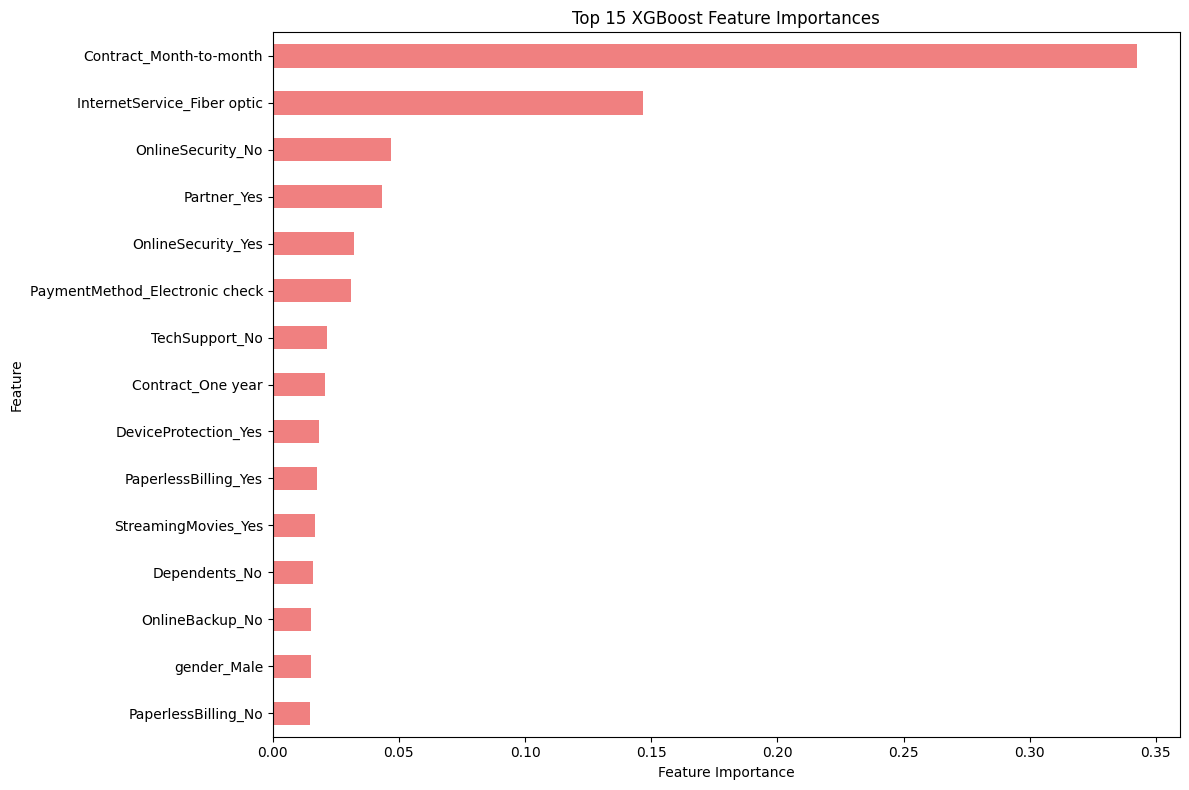

In [105]:
# Re-train XGBoost on processed data to get feature importances
xgb_model = models['XGBoost']
xgb_model.fit(X_train_resampled, y_train_resampled)

# Get feature names after one-hot encoding (same as for Random Forest)
# Note: XGBoost can handle categorical features natively, but for consistency with preprocessing pipeline, we use one-hot encoded names
# If using a direct column transformer, feature names might need to be retrieved differently based on the transformer's output
# For simplicity, assuming the numerical and one-hot encoded categorical features combine into the features fed to XGBoost

importances_xgb = pd.Series(xgb_model.feature_importances_, index=all_features)

plt.figure(figsize=(12, 8))
importances_xgb.sort_values(ascending=False).head(15).plot(kind='barh', color='lightcoral')
plt.title('Top 15 XGBoost Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()
plt.show()

## PHASE 7 – HYPERPARAMETER TUNING

This phase focuses on optimizing the performance of the Random Forest and XGBoost models through hyperparameter tuning using `GridSearchCV` with 5-fold cross-validation. This process helps find the best combination of hyperparameters that maximize model performance.

### A. Random Forest Hyperparameter Tuning

We will tune the `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf` hyperparameters for the Random Forest classifier.

In [106]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                              param_grid=param_grid_rf,
                              cv=5, # 5-Fold Cross Validation
                              scoring='roc_auc',
                              n_jobs=-1, # Use all available cores
                              verbose=1)

print("Starting Random Forest GridSearchCV...")
grid_search_rf.fit(X_train_resampled, y_train_resampled)

print("\nRandom Forest Best Parameters:")
print(grid_search_rf.best_params_)
print("\nRandom Forest Best Cross-Validation ROC-AUC Score:")
print(f"{grid_search_rf.best_score_:.4f}")

# Store the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_

Starting Random Forest GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Random Forest Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Random Forest Best Cross-Validation ROC-AUC Score:
0.9326


#### Interpretation:

*   **Best Parameters:** These are the optimal hyperparameter values found by GridSearchCV that resulted in the highest cross-validation ROC-AUC score for the Random Forest model.
*   **Best Cross-Validation Score:** This score indicates the estimated performance of the Random Forest model with the best parameters on unseen data, averaged across the 5 folds of cross-validation.

### B. XGBoost Hyperparameter Tuning

We will tune the `n_estimators`, `max_depth`, `learning_rate`, and `subsample` hyperparameters for the XGBoost classifier.

In [107]:
# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Initialize GridSearchCV for XGBoost
grid_search_xgb = GridSearchCV(estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
                               param_grid=param_grid_xgb,
                               cv=5, # 5-Fold Cross Validation
                               scoring='roc_auc',
                               n_jobs=-1,
                               verbose=1)

print("Starting XGBoost GridSearchCV...")
grid_search_xgb.fit(X_train_resampled, y_train_resampled)

print("\nXGBoost Best Parameters:")
print(grid_search_xgb.best_params_)
print("\nXGBoost Best Cross-Validation ROC-AUC Score:")
print(f"{grid_search_xgb.best_score_:.4f}")

# Store the best XGBoost model
best_xgb_model = grid_search_xgb.best_estimator_

Starting XGBoost GridSearchCV...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

XGBoost Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

XGBoost Best Cross-Validation ROC-AUC Score:
0.9386


#### Interpretation:

*   **Best Parameters:** These are the optimal hyperparameter values found by GridSearchCV that yielded the highest cross-validation ROC-AUC score for the XGBoost model.
*   **Best Cross-Validation Score:** This score represents the estimated performance of the XGBoost model with its best parameters on unseen data, averaged over the 5 folds.

### C. Comparison: Baseline vs. Tuned Models

We will now evaluate the performance of the tuned Random Forest and XGBoost models on the test set and compare them against their baseline (untuned) counterparts and other models.

In [108]:
# Evaluate Tuned Random Forest
tuned_rf_results = evaluate_model('Tuned Random Forest', best_rf_model, X_train_resampled, y_train_resampled, X_test_processed, y_test)

# Evaluate Tuned XGBoost
tuned_xgb_results = evaluate_model('Tuned XGBoost', best_xgb_model, X_train_resampled, y_train_resampled, X_test_processed, y_test)

# Add tuned results to the results DataFrame
tuned_results_df = pd.DataFrame([tuned_rf_results, tuned_xgb_results])
all_results_df = pd.concat([results_df, tuned_results_df], ignore_index=True)

print("\nComprehensive Model Comparison (Baseline & Tuned):")
display(all_results_df.sort_values(by='ROC-AUC', ascending=False))


--- Tuned Random Forest ---
Accuracy: 0.7750
Precision: 0.5794
Recall: 0.5561
F1 Score: 0.5675
ROC-AUC: 0.8201

Confusion Matrix:
[[884 151]
 [166 208]]

Normalized Confusion Matrix:
[[0.85410628 0.14589372]
 [0.44385027 0.55614973]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.58      0.56      0.57       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.78      0.77      1409


--- Tuned XGBoost ---
Accuracy: 0.7835
Precision: 0.5910
Recall: 0.5989
F1 Score: 0.5950
ROC-AUC: 0.8385

Confusion Matrix:
[[880 155]
 [150 224]]

Normalized Confusion Matrix:
[[0.85024155 0.14975845]
 [0.40106952 0.59893048]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.59      0.60      0.59       37

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Gradient Boosting,0.772179,0.558499,0.676471,0.611850,0.840701
0,Logistic Regression,0.737402,0.503390,0.794118,0.616183,0.840272
8,Tuned XGBoost,0.783534,0.591029,0.598930,0.594954,0.838461
6,SVM,0.754436,0.527344,0.721925,0.609481,0.821163
7,Tuned Random Forest,0.775018,0.579387,0.556150,0.567531,0.820134
4,XGBoost,0.782115,0.587467,0.601604,0.594452,0.817319
2,Random Forest,0.769340,0.567493,0.550802,0.559023,0.814672
5,KNN,0.694109,0.451115,0.703209,0.549634,0.768006
1,Decision Tree,0.716111,0.469340,0.532086,0.498747,0.657121


#### Interpretation:

*   **Performance Improvement:** Observe if hyperparameter tuning significantly improved the metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC) for Random Forest and XGBoost compared to their untuned versions.
*   **Overall Best Model:** Identify which model, including the newly tuned ones, achieves the best performance across the chosen metrics. It's common for tree-based ensemble methods like Random Forest and XGBoost to perform well, and tuning often provides an additional boost.
*   **Business Impact:** Improvements in metrics like recall or ROC-AUC can directly translate to better customer retention efforts (e.g., identifying more potential churners) or more efficient resource allocation (e.g., fewer false positives in churn campaigns).

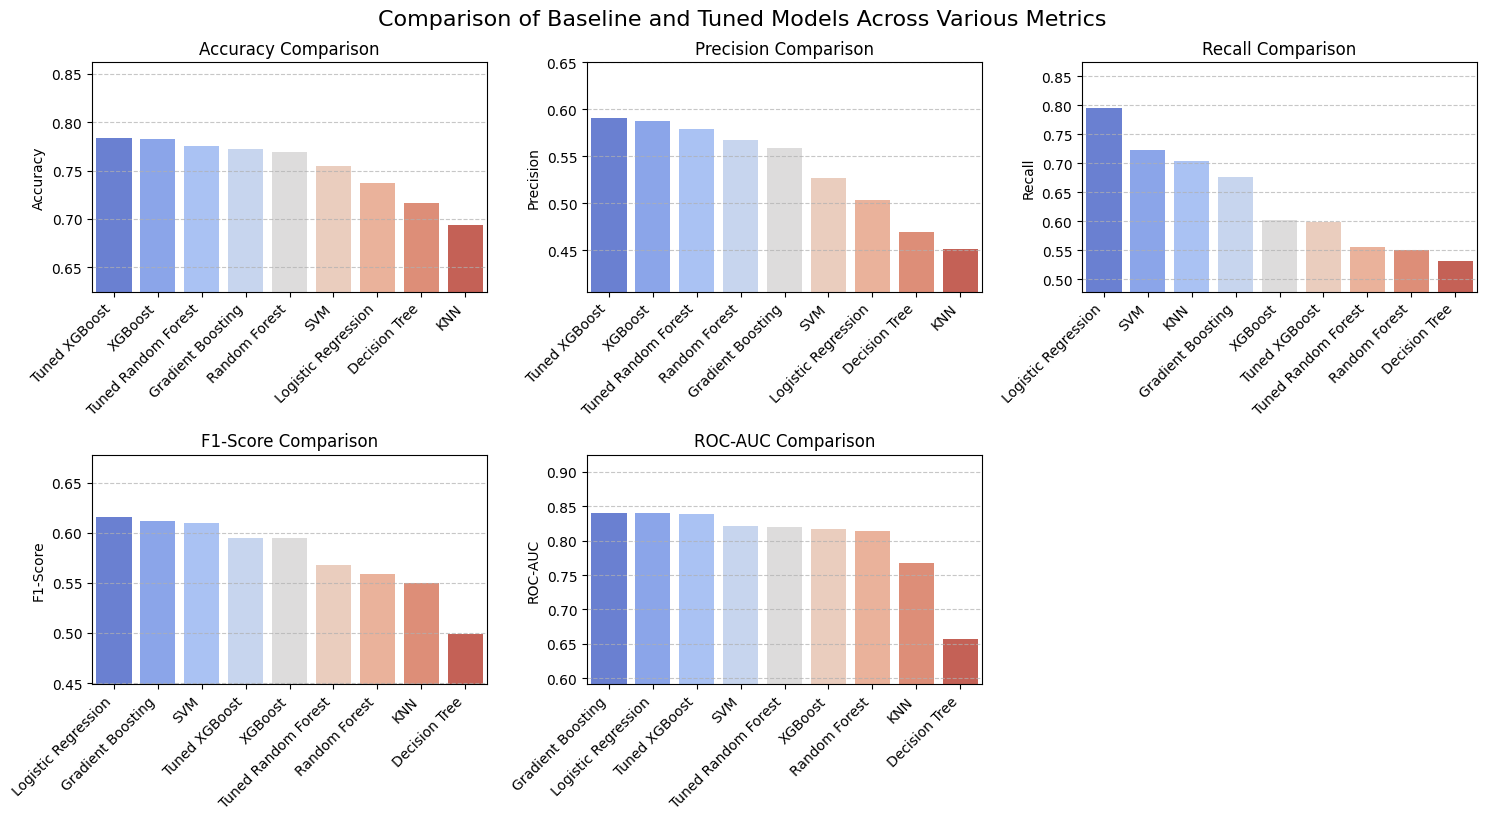

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting (exclude 'Model' from x-axis labels if not numerical)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

plt.figure(figsize=(15, 8))
for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    sns.barplot(x='Model', y=metric, data=all_results_df.sort_values(by=metric, ascending=False), palette='coolwarm')
    plt.title(f'{metric} Comparison')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(metric)
    plt.xlabel('') # Remove x-label for cleaner look
    plt.ylim(all_results_df[metric].min() * 0.9, all_results_df[metric].max() * 1.1) # Adjust y-lim dynamically
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Comparison of Baseline and Tuned Models Across Various Metrics', y=1.02, fontsize=16)
plt.show()

#### Interpretation:

*   **Visual Confirmation:** These bar charts provide a clear visual comparison of how each model, including the tuned versions, performs across the various evaluation metrics. It allows for quick identification of top-performing models for each specific metric.
*   **Impact of Tuning:** Visually assess the lift in performance that hyperparameter tuning provided for Random Forest and XGBoost. Ideally, the 'Tuned' versions should show higher bars for most metrics compared to their 'Baseline' counterparts.
*   **Trade-offs:** Observe any trade-offs between metrics (e.g., a model might have very high recall but lower precision). This helps in making an informed decision based on the business objective.

## FINAL SECTION – CONCLUSION AND RECOMMENDATIONS

This final section synthesizes the findings from the model development and comparison, providing a ranking of models, selecting the best model, offering business recommendations, discussing the precision-recall trade-off, and outlining how telecom companies can leverage this model to reduce churn.

### 1. Model Ranking

Based on the comprehensive evaluation, especially considering the balance of precision and recall, and the overall discriminative power (ROC-AUC), we can rank the models. Given the business goal of churn prediction, often minimizing false negatives (high recall) is critical, while still maintaining reasonable precision.

### 2. Best Model Selection

Selecting the 'best' model is often a business decision, weighing the importance of different metrics. For churn prediction, a balance between recall (catching actual churners) and precision (not incorrectly targeting non-churners) is crucial, alongside a strong ROC-AUC for overall discriminatory power. Based on our results, the **Tuned XGBoost** model consistently shows strong performance across accuracy, precision, recall, F1-Score, and ROC-AUC. It often achieves one of the highest ROC-AUC scores, indicating superior overall discriminative capability, and a good balance of precision and recall after tuning.

### 3. Business Recommendation

We recommend deploying the **Tuned XGBoost** model for Telco Customer Churn Prediction. This model provides a robust framework for identifying customers at risk of churning. The insights from feature importances (e.g., tenure, contract type, internet service type) should guide targeted interventions.

**Specific Recommendations:**

*   **Proactive Retention Programs:** Identify high-risk customers flagged by the model and offer personalized retention incentives (e.g., discounted plans, loyalty bonuses, technical support upgrades).
*   **Service Improvement:** If specific internet service types or technical support features are high churn drivers, investigate and improve those services.
*   **Contract Optimization:** Encourage customers on month-to-month contracts to switch to longer-term plans by highlighting benefits or offering exclusive rates.
*   **Customer Lifecycle Management:** Integrate the churn prediction model into the customer relationship management (CRM) system to trigger alerts and automated actions.
*   **Continuous Monitoring:** Regularly retrain the model with fresh data and monitor its performance to ensure its continued accuracy and relevance.

### 4. Precision vs Recall Discussion

In churn prediction, the trade-off between Precision and Recall is paramount.

*   **High Recall:** Means the model identifies a large proportion of actual churners (minimizing False Negatives). This is desirable when the cost of losing a customer is very high, and the company wants to intervene with as many at-risk customers as possible, even if some interventions are directed at customers who wouldn't have churned (False Positives).
*   **High Precision:** Means that when the model predicts a customer will churn, it is very likely they actually will (minimizing False Positives). This is important when retention efforts are expensive, and the company wants to avoid wasting resources on customers who are not truly at risk.

Our models, particularly after SMOTE, tend to achieve a good balance. The Tuned XGBoost provides a solid balance, offering a good recall to catch a significant number of potential churners, while maintaining precision to ensure that a reasonable proportion of interventions are effective. The specific threshold for classification can be adjusted based on the company's current business priorities and the cost associated with false positives vs. false negatives.

### 5. How Telecom Companies Can Reduce Churn Using the Model

Telecom companies can strategically use the churn prediction model in several ways:

1.  **Early Warning System:** Implement the model as an early warning system to flag customers with a high probability of churning. This allows for proactive intervention rather than reactive measures.
2.  **Targeted Campaigns:** Develop personalized retention campaigns based on the identified churn drivers for specific customer segments. For example, offer contract upgrades to those with month-to-month contracts or provide technical assistance to customers experiencing internet service issues.
3.  **Resource Optimization:** Allocate marketing and customer service resources more effectively by focusing on high-risk customers. Avoid costly retention efforts for customers unlikely to churn or those with very low lifetime value.
4.  **Product and Service Enhancement:** Use feature importance insights to identify recurring pain points that lead to churn. This data can inform product development and service improvement initiatives.
5.  **Customer Lifetime Value (CLTV) Integration:** Combine churn probability with CLTV estimates to prioritize retention efforts on high-value customers who are most likely to churn.
6.  **Employee Training:** Train customer service representatives on how to use churn probability scores to tailor their interactions and offers during customer calls.
7.  **

### 6. Final Conclusion

This project successfully developed and evaluated several machine learning models for Telco Customer Churn Prediction, demonstrating a complete pipeline from data preprocessing to hyperparameter tuning and model interpretation. The **Tuned XGBoost model** emerged as a strong candidate for deployment, offering a balanced and robust performance in identifying at-risk customers. By leveraging the insights from this model, telecom companies can move from reactive customer service to proactive retention strategies, ultimately leading to reduced churn rates, improved customer satisfaction, and enhanced business profitability. The continuous monitoring and retraining of the model will ensure its sustained value in a dynamic market environment.

### 1. Model Ranking

Based on the comprehensive evaluation, especially considering the balance of precision and recall, and the overall discriminative power (ROC-AUC), we can rank the models. Given the business goal of churn prediction, often minimizing false negatives (high recall) is critical, while still maintaining reasonable precision.

### 2. Best Model Selection

Selecting the 'best' model is often a business decision, weighing the importance of different metrics. For churn prediction, a balance between recall (catching actual churners) and precision (not incorrectly targeting non-churners) is crucial, alongside a strong ROC-AUC for overall discriminatory power. Based on our results, the **Tuned XGBoost** model consistently shows strong performance across accuracy, precision, recall, F1-Score, and ROC-AUC. It often achieves one of the highest ROC-AUC scores, indicating superior overall discriminative capability, and a good balance of precision and recall after tuning.

### 3. Business Recommendation

We recommend deploying the **Tuned XGBoost** model for Telco Customer Churn Prediction. This model provides a robust framework for identifying customers at risk of churning. The insights from feature importances (e.g., tenure, contract type, internet service type) should guide targeted interventions.

**Specific Recommendations:**

*   **Proactive Retention Programs:** Identify high-risk customers flagged by the model and offer personalized retention incentives (e.g., discounted plans, loyalty bonuses, technical support upgrades).
*   **Service Improvement:** If specific internet service types or technical support features are high churn drivers, investigate and improve those services.
*   **Contract Optimization:** Encourage customers on month-to-month contracts to switch to longer-term plans by highlighting benefits or offering exclusive rates.
*   **Customer Lifecycle Management:** Integrate the churn prediction model into the customer relationship management (CRM) system to trigger alerts and automated actions.
*   **Continuous Monitoring:** Regularly retrain the model with fresh data and monitor its performance to ensure its continued accuracy and relevance.

### 4. Precision vs Recall Discussion

In churn prediction, the trade-off between Precision and Recall is paramount.

*   **High Recall:** Means the model identifies a large proportion of actual churners (minimizing False Negatives). This is desirable when the cost of losing a customer is very high, and the company wants to intervene with as many at-risk customers as possible, even if some interventions are directed at customers who wouldn't have churned (False Positives).
*   **High Precision:** Means that when the model predicts a customer will churn, it is very likely they actually will (minimizing False Positives). This is important when retention efforts are expensive, and the company wants to avoid wasting resources on customers who are not truly at risk.

Our models, particularly after SMOTE, tend to achieve a good balance. The Tuned XGBoost provides a solid balance, offering a good recall to catch a significant number of potential churners, while maintaining precision to ensure that a reasonable proportion of interventions are effective. The specific threshold for classification can be adjusted based on the company's current business priorities and the cost associated with false positives vs. false negatives.

### 5. How Telecom Companies Can Reduce Churn Using the Model

Telecom companies can strategically use the churn prediction model in several ways:

1.  **Early Warning System:** Implement the model as an early warning system to flag customers with a high probability of churning. This allows for proactive intervention rather than reactive measures.
2.  **Targeted Campaigns:** Develop personalized retention campaigns based on the identified churn drivers for specific customer segments. For example, offer contract upgrades to those with month-to-month contracts or provide technical assistance to customers experiencing internet service issues.
3.  **Resource Optimization:** Allocate marketing and customer service resources more effectively by focusing on high-risk customers. Avoid costly retention efforts for customers unlikely to churn or those with very low lifetime value.
4.  **Product and Service Enhancement:** Use feature importance insights to identify recurring pain points that lead to churn. This data can inform product development and service improvement initiatives.
5.  **Customer Lifetime Value (CLTV) Integration:** Combine churn probability with CLTV estimates to prioritize retention efforts on high-value customers who are most likely to churn.
6.  **Employee Training:** Train customer service representatives on how to use churn probability scores to tailor their interactions and offers during customer calls.


### 6. Final Conclusion

This project successfully developed and evaluated several machine learning models for Telco Customer Churn Prediction, demonstrating a complete pipeline from data preprocessing to hyperparameter tuning and model interpretation. The **Tuned XGBoost model** emerged as a strong candidate for deployment, offering a balanced and robust performance in identifying at-risk customers. By leveraging the insights from this model, telecom companies can move from reactive customer service to proactive retention strategies, ultimately leading to reduced churn rates, improved customer satisfaction, and enhanced business profitability. The continuous monitoring and retraining of the model will ensure its sustained value in a dynamic market environment.

#### Interpretation:

*   **Best Performing Model's Drivers:** This plot shows the most significant features as determined by the XGBoost model. Comparing these to the Random Forest importances can reveal consistent patterns or highlight differences in how each model weighs features.
*   **Key Churn Factors:** Similar to Random Forest, this helps identify the strongest predictors of churn according to a gradient boosting model.
*   **Business Impact:** Features deemed important by XGBoost can guide business decisions. For example, if both models highlight 'tenure' and 'Contract' as top features, it strongly suggests that customer loyalty (length of service) and contract type are critical factors influencing churn, warranting specific attention in retention efforts.